# K* Means Clustering - Level 2 (Hierarchical)

This notebook implements the second level of K* means clustering by:
1. Loading Level 1 clustering results
2. Computing centroids for each Level 1 cluster (reducing each cluster to 1 point)
3. Applying K* means on these centroids to create Level 2 clusters

**Key Concept:** Each Level 1 cluster becomes a single point (its centroid) for Level 2 clustering.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## K* Means Implementation

Reusing the same K* Means class from Level 1.

In [13]:
class KStarMeans:
    """K*-means clustering with automatic K determination using MDL principle.
    
    Implements the algorithm from the paper with proper split/merge operations.
    """
    def __init__(self, patience=5):
        self.patience = patience    # termination criteria
        self.centroids = None
        self.labels = None
        self.sub_centroids = {}     # Stores (mu_s1, mu_s2) for each cluster
        self.clusters = {}          # Stores actual cluster assignments

    def _mdl_cost(self, X, centroids, labels):
        """Calculate MDL cost as per pseudocode: modelcost + idxcost + residualcost"""
        N, d = X.shape
        k = len(centroids)
        if k == 0: return np.inf
        
        # Calculate float precision from data
        flat_X = X.flatten()
        unique_vals = np.unique(flat_X)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            if min_dist > 0:
                floatprecision = -np.log2(min_dist)
            else:
                floatprecision = 10.0
        else:
            floatprecision = 10.0
        
        # Model Cost: |C| * d * floatcost
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index Cost: |X| * log(|C|)
        idxcost = N * np.log2(k) if k > 1 else 0
        
        # Residual Cost: sum of squared distances from centroids
        c = 0
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                c += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = 0.5 * (N * d * np.log2(2 * np.pi) + c)
        
        return modelcost + idxcost + residualcost

    def _init_subcentroids(self, cluster_data):
        """Initialize two subcentroids using k-means++."""
        if len(cluster_data) < 2:
            return cluster_data[0], cluster_data[0]
        centers, _ = kmeans_plusplus(cluster_data, n_clusters=2)
        return centers[0], centers[1]

    def _kmeans_step(self, X):
        """Perform one iteration of k-means assignment and update."""
        # Assign points to nearest centroid
        dists = np.linalg.norm(X[:, np.newaxis] - np.array(self.centroids), axis=2)
        self.labels = np.argmin(dists, axis=1)
        
        # Update centroids and subclusters
        for i in range(len(self.centroids)):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                # Update main centroid
                self.centroids[i] = np.mean(cluster_points, axis=0)
                
                # Update sub-centroids if cluster has enough points
                if len(cluster_points) >= 2:
                    if i not in self.sub_centroids or len(cluster_points) == 2:
                        self.sub_centroids[i] = self._init_subcentroids(cluster_points)
                    else:
                        # Update existing subcentroids
                        s1, s2 = self.sub_centroids[i]
                        d1 = np.linalg.norm(cluster_points - s1, axis=1)
                        d2 = np.linalg.norm(cluster_points - s2, axis=1)
                        sub_labels = d1 < d2
                        
                        if np.any(sub_labels) and np.any(~sub_labels):
                            s1_new = np.mean(cluster_points[sub_labels], axis=0)
                            s2_new = np.mean(cluster_points[~sub_labels], axis=0)
                            self.sub_centroids[i] = (s1_new, s2_new)

    def _maybe_split(self, X):
        """Try to split the cluster that would most reduce MDL cost."""
        N = len(X)
        k = len(self.centroids)
        current_cost = self._mdl_cost(X, self.centroids, self.labels)
        best_cost = current_cost
        split_at = -1
        
        # Try splitting each cluster and calculate actual MDL cost
        for i in range(k):
            cluster_points = X[self.labels == i]
            if len(cluster_points) < 2 or i not in self.sub_centroids:
                continue
            
            # Get subclusters
            s1, s2 = self.sub_centroids[i]
            d1 = np.linalg.norm(cluster_points - s1, axis=1)
            d2 = np.linalg.norm(cluster_points - s2, axis=1)
            
            # Simulate split: temporarily create new clustering
            temp_centroids = self.centroids.copy()
            temp_centroids[i] = s1.copy()
            temp_centroids.append(s2.copy())
            
            # Reassign labels with new centroids
            dists = np.linalg.norm(X[:, np.newaxis] - np.array(temp_centroids), axis=2)
            temp_labels = np.argmin(dists, axis=1)
            
            # Calculate actual MDL cost with this split
            split_cost = self._mdl_cost(X, temp_centroids, temp_labels)
            
            if split_cost < best_cost:
                best_cost = split_cost
                split_at = i
        
        # Perform split if it reduces cost
        did_split = False
        split_info = None
        if split_at >= 0 and best_cost < current_cost:
            s1, s2 = self.sub_centroids[split_at]
            # Replace old centroid with s1, add s2 as new centroid
            self.centroids[split_at] = s1.copy()
            self.centroids.append(s2.copy())
            
            # Re-assign all points
            self._kmeans_step(X)
            
            # Initialize new subcentroids for both split clusters
            for idx in [split_at, len(self.centroids)-1]:
                cluster_points = X[self.labels == idx]
                if len(cluster_points) >= 2:
                    self.sub_centroids[idx] = self._init_subcentroids(cluster_points)
            
            did_split = True
            split_info = (split_at, len(self.centroids), current_cost, best_cost)
        
        return did_split, split_info

    def _maybe_merge(self, X):
        """Try to merge the closest pair of centroids if it reduces MDL cost."""
        N = len(X)
        k = len(self.centroids)
        if k < 2:
            return False, None
        
        current_cost = self._mdl_cost(X, self.centroids, self.labels)
        best_cost = current_cost
        merge_pair = None
        
        # Try merging each pair of closest centroids
        centroids_array = np.array(self.centroids)
        
        # Find all pairs and their distances
        for i1 in range(k):
            for i2 in range(i1 + 1, k):
                # Simulate merge
                cluster1 = X[self.labels == i1]
                cluster2 = X[self.labels == i2]
                Z = np.vstack([cluster1, cluster2])
                m_merged = np.mean(Z, axis=0)
                
                # Create temporary centroids with merge
                temp_centroids = [self.centroids[j] for j in range(k) if j not in [i1, i2]]
                temp_centroids.append(m_merged)
                
                # Reassign labels with merged centroids
                dists = np.linalg.norm(X[:, np.newaxis] - np.array(temp_centroids), axis=2)
                temp_labels = np.argmin(dists, axis=1)
                
                # Calculate actual MDL cost with this merge
                merge_cost = self._mdl_cost(X, temp_centroids, temp_labels)
                
                if merge_cost < best_cost:
                    best_cost = merge_cost
                    merge_pair = (i1, i2, m_merged)
        
        # Perform merge if it reduces cost
        did_merge = False
        merge_info = None
        if merge_pair is not None and best_cost < current_cost:
            i1, i2, m_merged = merge_pair
            old_k = len(self.centroids)
            
            # Remove both clusters and add merged
            if i1 > i2:
                i1, i2 = i2, i1
            
            # Replace first centroid with merged, remove second
            self.centroids[i1] = m_merged
            del self.centroids[i2]
            
            # Update subcentroids dictionary
            if i2 in self.sub_centroids:
                del self.sub_centroids[i2]
            
            # Re-assign all points
            self._kmeans_step(X)
            
            # Reinitialize subcentroids for merged cluster
            cluster_points = X[self.labels == i1]
            if len(cluster_points) >= 2:
                self.sub_centroids[i1] = self._init_subcentroids(cluster_points)
            
            did_merge = True
            merge_info = (i1, i2, old_k, len(self.centroids), current_cost, best_cost)
        
        return did_merge, merge_info

    def fit(self, X):
        """Fit K*-means to data X following the pseudocode algorithm."""
        N, d = X.shape
        
        # Initialize with one cluster
        self.centroids = [np.mean(X, axis=0)]
        self.labels = np.zeros(N, dtype=int)
        self.sub_centroids = {0: self._init_subcentroids(X)}
        
        best_cost = np.inf
        unimproved_count = 0
        iteration = 0
        
        print("Starting K* Means iterations (Level 2)...")
        print("="*70)
        
        while True:
            iteration += 1
            
            # KmeansStep
            self._kmeans_step(X)
            
            # MaybeSplit
            did_split, split_info = self._maybe_split(X)
            
            # If no split, do KmeansStep again then MaybeMerge
            did_merge = False
            merge_info = None
            if not did_split:
                self._kmeans_step(X)
                did_merge, merge_info = self._maybe_merge(X)
            
            # Calculate cost and check improvement
            cost = self._mdl_cost(X, self.centroids, self.labels)
            k = len(self.centroids)
            
            # Print iteration info
            action = ""
            if did_split:
                action = f"✂️  SPLIT cluster {split_info[0]} → K={split_info[1]} (MDL: {split_info[2]:.0f}→{split_info[3]:.0f})"
            elif did_merge:
                action = f"🔗 MERGE clusters {merge_info[0]} & {merge_info[1]}: K={merge_info[2]}→{merge_info[3]} (MDL: {merge_info[4]:.0f}→{merge_info[5]:.0f})"
            else:
                action = "⏸️  No split/merge"
            
            improvement = ""
            if cost < best_cost:
                best_cost = cost
                unimproved_count = 0
                improvement = "✓ Cost improved"
            else:
                unimproved_count += 1
                improvement = f"✗ No improvement ({unimproved_count}/{self.patience})"
            
            print(f"Iter {iteration:2d} | K={k:2d} | {action:40s} | {improvement}")
            
            # Termination condition
            if unimproved_count >= self.patience:
                print("="*70)
                print(f"Converged after {iteration} iterations with K={k} clusters")
                break
        
        return self

    def predict(self, X):
        """Predict cluster labels for new data."""
        dists = np.linalg.norm(X[:, np.newaxis] - np.array(self.centroids), axis=2)
        return np.argmin(dists, axis=1)

print("✓ KStarMeans class defined")

✓ KStarMeans class defined


## Load Level 1 Clustering Results

Load the results from the first level clustering.

In [14]:
# Load Level 1 results
input_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv"
print("Loading Level 1 clustering results...")
df_level1 = pd.read_csv(input_file)

print(f"Level 1 Results:")
print(f"  Total samples: {len(df_level1):,}")
print(f"  Number of L1 clusters: {df_level1['Cluster'].nunique()}")
print(f"  Features: {len(df_level1.columns) - 3}  (excluding Cluster, PCA_1, PCA_2)")
print(f"\n✓ Level 1 results loaded successfully")

Loading Level 1 clustering results...
Level 1 Results:
  Total samples: 7,043
  Number of L1 clusters: 42
  Features: 72  (excluding Cluster, PCA_1, PCA_2)

✓ Level 1 results loaded successfully


## Compute Level 1 Centroids

**Key Step:** Each Level 1 cluster is reduced to a single point (its centroid).

This follows the hierarchical clustering logic:
- Level 0: Individual data points (e.g., 7043 customers)
- Level 1: K₁ clusters (e.g., 5 clusters)
- Level 2: Cluster the K₁ centroids → K₂ clusters (e.g., 2-3 clusters)

**Example:** If Level 1 has 5 clusters, we compute 5 centroids (one per cluster), then cluster those 5 points.

In [15]:
# Get feature columns (exclude Cluster, PCA_1, PCA_2)
exclude_cols = ['Cluster', 'PCA_1', 'PCA_2']
feature_cols = [col for col in df_level1.columns if col not in exclude_cols]

print(f"Feature columns: {len(feature_cols)}")
print(f"\nComputing centroid for each Level 1 cluster...\n")

# Compute centroid for each Level 1 cluster
l1_cluster_ids = sorted(df_level1['Cluster'].unique())
centroids_list = []

print("Level 1 Cluster Summary:")
print("="*70)
for cluster_id in l1_cluster_ids:
    cluster_data = df_level1[df_level1['Cluster'] == cluster_id][feature_cols].values
    centroid = np.mean(cluster_data, axis=0)
    centroids_list.append(centroid)
    
    print(f"L1 Cluster {cluster_id}: {len(cluster_data):5,} points → 1 centroid (shape: {centroid.shape})")

# Convert to numpy array
X_centroids = np.array(centroids_list)

print("="*70)
print(f"\n✓ Level 2 input data prepared:")
print(f"  - {X_centroids.shape[0]} centroids (one per L1 cluster)")
print(f"  - {X_centroids.shape[1]} dimensions (same as original features)")
print(f"  - Each centroid represents ALL points from its L1 cluster")

Feature columns: 72

Computing centroid for each Level 1 cluster...

Level 1 Cluster Summary:
L1 Cluster 0:   512 points → 1 centroid (shape: (72,))
L1 Cluster 1:   257 points → 1 centroid (shape: (72,))
L1 Cluster 2:   330 points → 1 centroid (shape: (72,))
L1 Cluster 3:   154 points → 1 centroid (shape: (72,))
L1 Cluster 4:   258 points → 1 centroid (shape: (72,))
L1 Cluster 5:   130 points → 1 centroid (shape: (72,))
L1 Cluster 6:    19 points → 1 centroid (shape: (72,))
L1 Cluster 7:   222 points → 1 centroid (shape: (72,))
L1 Cluster 8:   159 points → 1 centroid (shape: (72,))
L1 Cluster 9:    13 points → 1 centroid (shape: (72,))
L1 Cluster 10:    57 points → 1 centroid (shape: (72,))
L1 Cluster 11:   103 points → 1 centroid (shape: (72,))
L1 Cluster 12:    20 points → 1 centroid (shape: (72,))
L1 Cluster 13:    89 points → 1 centroid (shape: (72,))
L1 Cluster 14:    53 points → 1 centroid (shape: (72,))
L1 Cluster 15:    98 points → 1 centroid (shape: (72,))
L1 Cluster 16:   134

## Perform Level 2 K* Means Clustering

Apply K* Means on the Level 1 centroids to create Level 2 hierarchy.

## Alternative: Use Regular K-Means for Level 2

When K* means is too conservative (finds only 1 cluster), we can use regular K-means with a fixed K.
This is actually what Hercules does - it uses fixed cluster counts or a different optimization method.

In [16]:
from sklearn.cluster import KMeans

# Function to determine optimal K using elbow method or silhouette
def find_optimal_k_for_level2(X_centroids, min_k=2, max_k=None):
    """Find optimal K for Level 2 clustering using multiple methods."""
    if max_k is None:
        max_k = min(15, X_centroids.shape[0] - 1)
    
    k_range = range(min_k, max_k + 1)
    silhouette_scores = []
    inertias = []
    
    print(f"Testing K from {min_k} to {max_k}...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_centroids)
        
        # Silhouette score
        if k > 1:
            sil_score = silhouette_score(X_centroids, labels)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0)
        
        inertias.append(kmeans.inertia_)
        print(f"  K={k}: Silhouette={silhouette_scores[-1]:.4f}, Inertia={inertias[-1]:.2f}")
    
    # Find K with best silhouette score
    best_k = k_range[np.argmax(silhouette_scores)]
    
    print(f"\n✓ Optimal K based on Silhouette Score: {best_k}")
    return best_k, list(k_range), silhouette_scores, inertias

# Find optimal K for Level 2
optimal_k_l2, k_values, sil_scores, inertias = find_optimal_k_for_level2(
    X_centroids, 
    min_k=2, 
    max_k=min(10, X_centroids.shape[0] - 1)
)

Testing K from 2 to 10...
  K=2: Silhouette=0.6547, Inertia=3131.15
  K=3: Silhouette=0.1299, Inertia=2724.56
  K=4: Silhouette=0.1477, Inertia=2373.85
  K=5: Silhouette=0.1553, Inertia=2190.78
  K=6: Silhouette=0.1605, Inertia=1741.39
  K=7: Silhouette=0.1689, Inertia=1639.38
  K=8: Silhouette=0.1751, Inertia=1427.10
  K=9: Silhouette=0.1814, Inertia=1296.06
  K=10: Silhouette=0.1872, Inertia=1174.43

✓ Optimal K based on Silhouette Score: 2


## Visualize K Selection Metrics

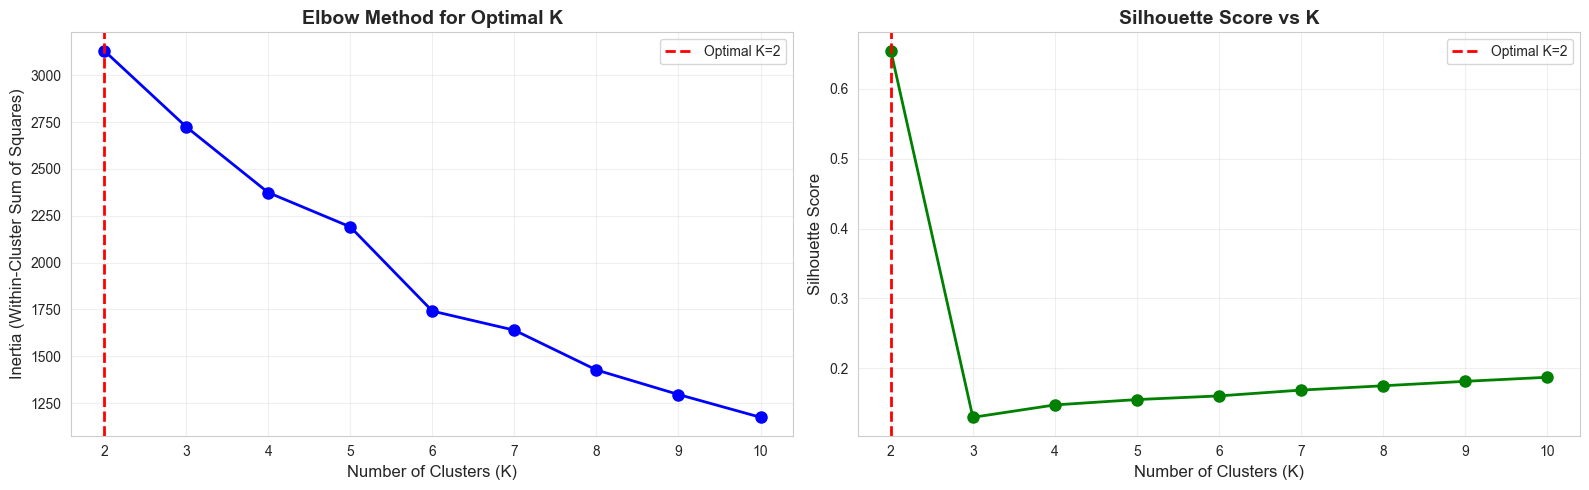


📊 Analysis suggests K=2 for Level 2 clustering


In [17]:
# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow curve
axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k_l2, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k_l2}')
axes[0].legend()

# Silhouette scores
axes[1].plot(k_values, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=optimal_k_l2, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k_l2}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Analysis suggests K={optimal_k_l2} for Level 2 clustering")

## Apply Regular K-Means with Optimal K

Now cluster the Level 1 centroids using regular K-means with the optimal K.

In [18]:
# Apply K-Means with optimal K
print(f"Applying K-Means with K={optimal_k_l2} on {X_centroids.shape[0]} Level 1 centroids...")

kmeans_l2 = KMeans(n_clusters=optimal_k_l2, random_state=42, n_init=20, max_iter=300)
l2_labels_for_l1_clusters = kmeans_l2.fit_predict(X_centroids)

# Get Level 2 results
k_level2 = optimal_k_l2
l2_centroids_array = kmeans_l2.cluster_centers_

print("\n" + "="*70)
print("LEVEL 2 CLUSTERING RESULTS (K-Means):")
print("="*70)
print(f"Level 2 clusters (K₂): {k_level2}")
print(f"Level 1 clusters (K₁): {X_centroids.shape[0]}")
print("="*70)

# Show which L1 clusters belong to which L2 cluster
print("\nLevel 2 Cluster Composition:")
for l2_cluster in range(k_level2):
    l1_clusters_in_l2 = [l1_cluster_ids[i] for i, label in enumerate(l2_labels_for_l1_clusters) if label == l2_cluster]
    print(f"  L2 Cluster {l2_cluster}: contains {len(l1_clusters_in_l2)} L1 clusters {l1_clusters_in_l2[:10]}{'...' if len(l1_clusters_in_l2) > 10 else ''}")

Applying K-Means with K=2 on 42 Level 1 centroids...

LEVEL 2 CLUSTERING RESULTS (K-Means):
Level 2 clusters (K₂): 2
Level 1 clusters (K₁): 42

Level 2 Cluster Composition:
  L2 Cluster 0: contains 41 L1 clusters [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  L2 Cluster 1: contains 1 L1 clusters [21]


In [19]:
# Initialize and fit K* Means on centroids
print("\nInitializing Level 2 K* Means clustering...")
print(f"Clustering {X_centroids.shape[0]} Level 1 centroids...\n")

kstar_l2 = KStarMeans(patience=5)
kstar_l2.fit(X_centroids)

# Get Level 2 results
k_level2 = len(kstar_l2.centroids)
l2_labels_for_l1_clusters = kstar_l2.labels

print("\n" + "="*70)
print("LEVEL 2 CLUSTERING RESULTS:")
print("="*70)
print(f"Level 2 clusters (K₂): {k_level2}")
print(f"Level 1 clusters (K₁): {X_centroids.shape[0]}")
print("="*70)

# Show which L1 clusters belong to which L2 cluster
print("\nLevel 2 Cluster Composition:")
for l2_cluster in range(k_level2):
    l1_clusters_in_l2 = [l1_cluster_ids[i] for i, label in enumerate(l2_labels_for_l1_clusters) if label == l2_cluster]
    print(f"  L2 Cluster {l2_cluster}: contains L1 clusters {l1_clusters_in_l2}")


Initializing Level 2 K* Means clustering...
Clustering 42 Level 1 centroids...

Starting K* Means iterations (Level 2)...
Iter  1 | K= 2 | ✂️  SPLIT cluster 0 → K=2 (MDL: 6203→6083) | ✓ Cost improved
Iter  2 | K= 3 | ✂️  SPLIT cluster 1 → K=3 (MDL: 6083→5589) | ✓ Cost improved
Iter  3 | K= 4 | ✂️  SPLIT cluster 0 → K=4 (MDL: 5589→5500) | ✓ Cost improved
Iter  4 | K= 4 | ⏸️  No split/merge                       | ✗ No improvement (1/5)
Iter  5 | K= 4 | ⏸️  No split/merge                       | ✗ No improvement (2/5)
Iter  6 | K= 4 | ⏸️  No split/merge                       | ✗ No improvement (3/5)
Iter  7 | K= 4 | ⏸️  No split/merge                       | ✗ No improvement (4/5)
Iter  8 | K= 4 | ⏸️  No split/merge                       | ✗ No improvement (5/5)
Converged after 8 iterations with K=4 clusters

LEVEL 2 CLUSTERING RESULTS:
Level 2 clusters (K₂): 4
Level 1 clusters (K₁): 42

Level 2 Cluster Composition:
  L2 Cluster 0: contains L1 clusters [1, 8, 9, 30, 31, 38, 40]
  L2 Clu

## Map Level 2 Labels to Original Data

Assign Level 2 cluster labels to all original data points based on their Level 1 membership.

In [20]:
# Create mapping from L1 cluster to L2 cluster
l1_to_l2_mapping = {l1_cluster_ids[i]: l2_labels_for_l1_clusters[i] for i in range(len(l1_cluster_ids))}

print("Level 1 → Level 2 Cluster Mapping:")
for l1_id, l2_id in l1_to_l2_mapping.items():
    print(f"  L1 Cluster {l1_id} → L2 Cluster {l2_id}")

# Assign L2 labels to all original points
df_level1['Cluster_L2'] = df_level1['Cluster'].map(l1_to_l2_mapping)

print(f"\n✓ Assigned Level 2 labels to {len(df_level1):,} data points")

# Summary statistics
print("\n" + "="*70)
print("LEVEL 2 CLUSTER DISTRIBUTION (Original Data Points):")
print("="*70)
for l2_cluster in sorted(df_level1['Cluster_L2'].unique()):
    count = (df_level1['Cluster_L2'] == l2_cluster).sum()
    percentage = (count / len(df_level1)) * 100
    l1_clusters = df_level1[df_level1['Cluster_L2'] == l2_cluster]['Cluster'].unique()
    print(f"L2 Cluster {l2_cluster}: {count:5,} points ({percentage:5.1f}%) from L1 clusters {sorted(l1_clusters)}")

Level 1 → Level 2 Cluster Mapping:
  L1 Cluster 0 → L2 Cluster 3
  L1 Cluster 1 → L2 Cluster 0
  L1 Cluster 2 → L2 Cluster 3
  L1 Cluster 3 → L2 Cluster 2
  L1 Cluster 4 → L2 Cluster 3
  L1 Cluster 5 → L2 Cluster 2
  L1 Cluster 6 → L2 Cluster 2
  L1 Cluster 7 → L2 Cluster 3
  L1 Cluster 8 → L2 Cluster 0
  L1 Cluster 9 → L2 Cluster 0
  L1 Cluster 10 → L2 Cluster 2
  L1 Cluster 11 → L2 Cluster 2
  L1 Cluster 12 → L2 Cluster 2
  L1 Cluster 13 → L2 Cluster 2
  L1 Cluster 14 → L2 Cluster 2
  L1 Cluster 15 → L2 Cluster 2
  L1 Cluster 16 → L2 Cluster 2
  L1 Cluster 17 → L2 Cluster 2
  L1 Cluster 18 → L2 Cluster 2
  L1 Cluster 19 → L2 Cluster 2
  L1 Cluster 20 → L2 Cluster 2
  L1 Cluster 21 → L2 Cluster 1
  L1 Cluster 22 → L2 Cluster 2
  L1 Cluster 23 → L2 Cluster 2
  L1 Cluster 24 → L2 Cluster 2
  L1 Cluster 25 → L2 Cluster 2
  L1 Cluster 26 → L2 Cluster 3
  L1 Cluster 27 → L2 Cluster 3
  L1 Cluster 28 → L2 Cluster 3
  L1 Cluster 29 → L2 Cluster 3
  L1 Cluster 30 → L2 Cluster 0
  L1 Cluster 3

## Evaluate Level 2 Clustering Quality

Calculate metrics for Level 2 clustering on the original data space.

In [21]:
# Calculate metrics on original data with L2 labels
X_original = df_level1[feature_cols].values
l2_labels_all = df_level1['Cluster_L2'].values

if k_level2 > 1:
    silhouette_l2 = silhouette_score(X_original, l2_labels_all)
    davies_bouldin_l2 = davies_bouldin_score(X_original, l2_labels_all)
    calinski_harabasz_l2 = calinski_harabasz_score(X_original, l2_labels_all)
    
    # Calculate inertia
    inertia_l2 = 0
    for i in range(k_level2):
        cluster_points = X_original[l2_labels_all == i]
        cluster_centroid = np.mean(cluster_points, axis=0)
        inertia_l2 += np.sum((cluster_points - cluster_centroid)**2)
    
    print("\n" + "="*70)
    print("LEVEL 2 CLUSTERING QUALITY METRICS:")
    print("="*70)
    print(f"Silhouette Score:        {silhouette_l2:.4f} (range: [-1, 1], higher is better)")
    print(f"Davies-Bouldin Index:    {davies_bouldin_l2:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {calinski_harabasz_l2:.2f} (higher is better)")
    print(f"Inertia (WCSS):          {inertia_l2:.2f}")
    print("="*70)
else:
    print("\n⚠ Only one Level 2 cluster - cannot calculate comparison metrics")


LEVEL 2 CLUSTERING QUALITY METRICS:
Silhouette Score:        0.1771 (range: [-1, 1], higher is better)
Davies-Bouldin Index:    1.9082 (lower is better)
Calinski-Harabasz Score: 767.04 (higher is better)
Inertia (WCSS):          382162.83


## Visualize Level 2 Hierarchy

Create visualizations showing both Level 1 and Level 2 cluster structures.

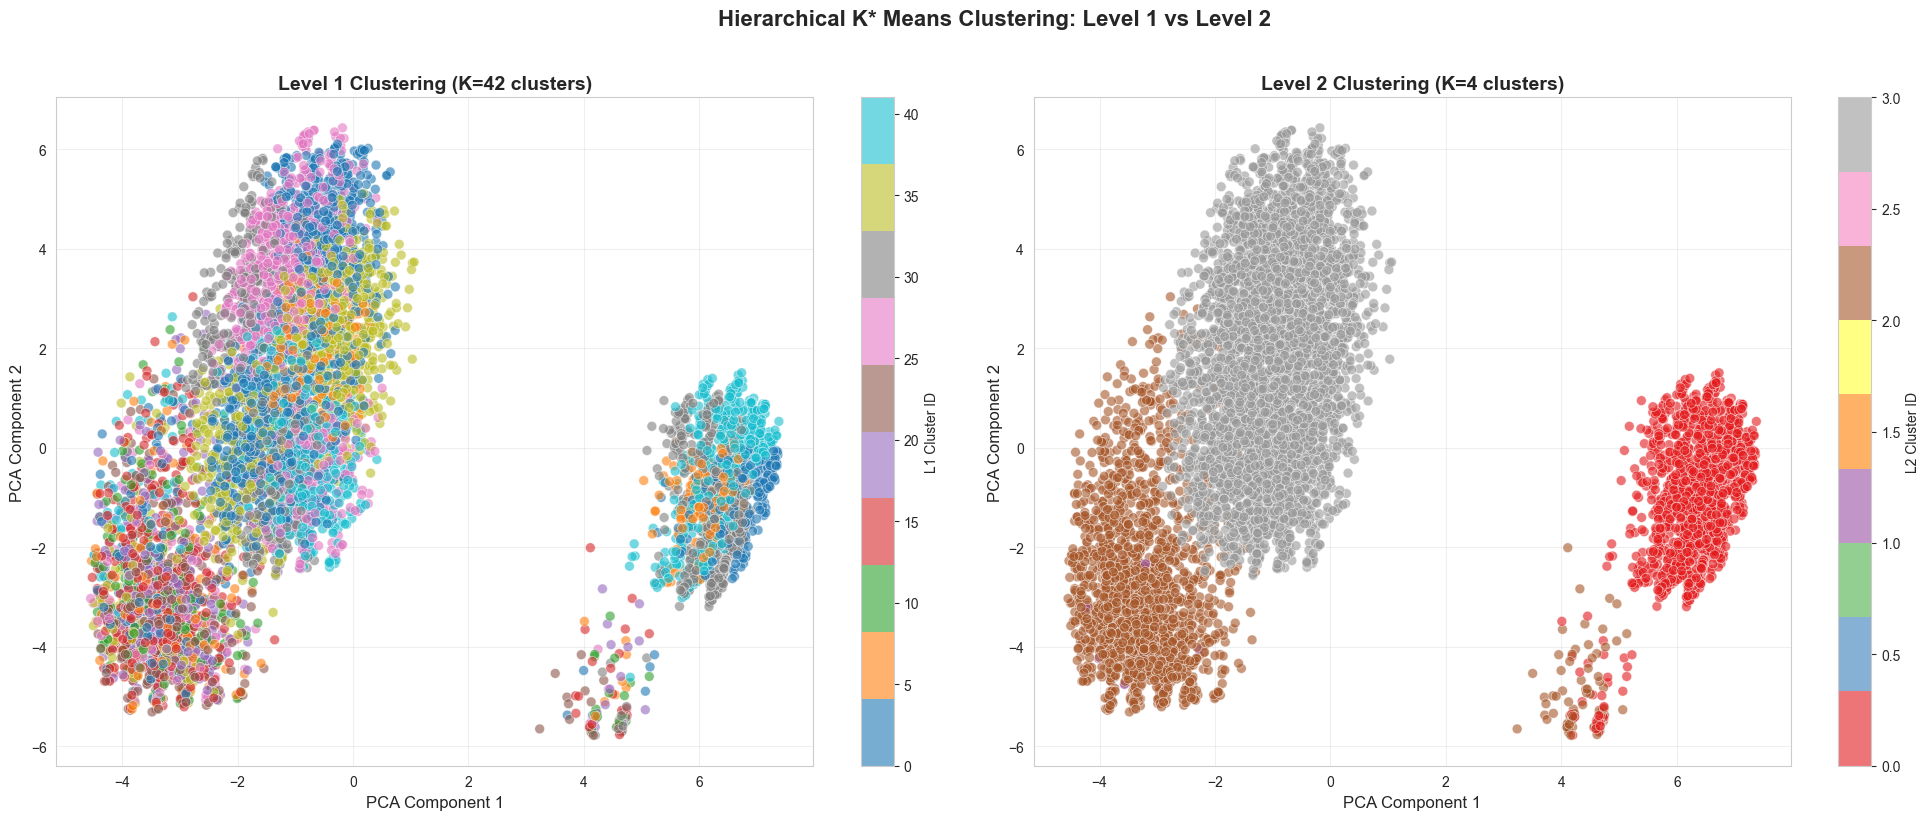

In [22]:
# Use existing PCA coordinates from Level 1
pca_coords = df_level1[['PCA_1', 'PCA_2']].values

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Level 1 clusters
scatter1 = axes[0].scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=df_level1['Cluster'],
    cmap='tab10',
    alpha=0.6, s=50,
    edgecolors='w', linewidth=0.5
)
axes[0].set_xlabel('PCA Component 1', fontsize=12)
axes[0].set_ylabel('PCA Component 2', fontsize=12)
axes[0].set_title(f'Level 1 Clustering (K={X_centroids.shape[0]} clusters)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='L1 Cluster ID')

# Plot Level 2 clusters
scatter2 = axes[1].scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=df_level1['Cluster_L2'],
    cmap='Set1',
    alpha=0.6, s=50,
    edgecolors='w', linewidth=0.5
)
axes[1].set_xlabel('PCA Component 1', fontsize=12)
axes[1].set_ylabel('PCA Component 2', fontsize=12)
axes[1].set_title(f'Level 2 Clustering (K={k_level2} clusters)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='L2 Cluster ID')

plt.suptitle('Hierarchical K* Means Clustering: Level 1 vs Level 2', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Visualize Level 1 Centroids and Level 2 Clustering

Show how the Level 1 centroids were clustered to create Level 2.

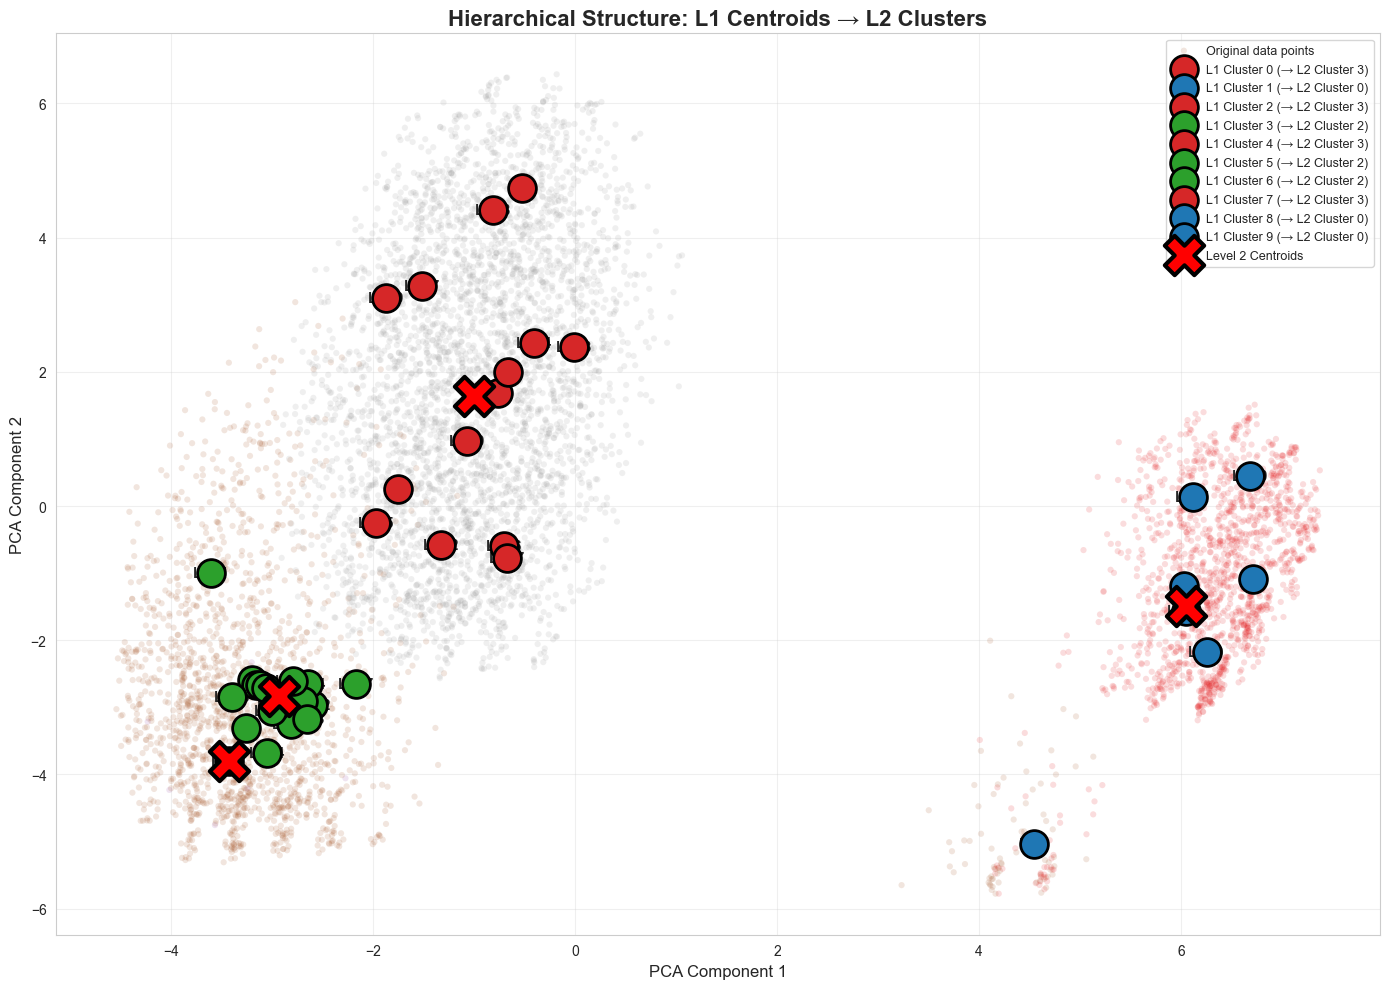


📊 Visualization Key:
  • Faded points: Original data (colored by L2 cluster)
  • Large circles: Level 1 centroids (labeled L1-X)
  • Red X marks: Level 2 centroids (labeled L2-X)


In [23]:
# Transform L1 centroids to PCA space for visualization
pca = PCA(n_components=2, random_state=42)
pca.fit(X_original)
centroids_pca = pca.transform(X_centroids)

# Also transform L2 centroids
l2_centroids_array = np.array(kstar_l2.centroids)
l2_centroids_pca = pca.transform(l2_centroids_array)

# Plot
plt.figure(figsize=(14, 10))

# Plot all original points with L2 colors (faded)
plt.scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=df_level1['Cluster_L2'],
    cmap='Set1',
    alpha=0.15, s=20,
    edgecolors='none',
    label='Original data points'
)

# Plot L1 centroids with L2 colors
for i, (l1_id, l2_label) in enumerate(zip(l1_cluster_ids, l2_labels_for_l1_clusters)):
    plt.scatter(
        centroids_pca[i, 0], centroids_pca[i, 1],
        c=f'C{l2_label}',
        marker='o',
        s=400,
        edgecolors='black',
        linewidth=2,
        label=f'L1 Cluster {l1_id} (→ L2 Cluster {l2_label})' if i < 10 else None,
        zorder=5
    )
    plt.annotate(f'L1-{l1_id}', (centroids_pca[i, 0], centroids_pca[i, 1]),
                fontsize=10, fontweight='bold', ha='center', va='center')

# Plot L2 centroids
plt.scatter(
    l2_centroids_pca[:, 0], l2_centroids_pca[:, 1],
    c='red',
    marker='X',
    s=800,
    edgecolors='black',
    linewidth=3,
    label='Level 2 Centroids',
    zorder=10
)
for i in range(len(l2_centroids_pca)):
    plt.annotate(f'L2-{i}', (l2_centroids_pca[i, 0], l2_centroids_pca[i, 1]),
                fontsize=12, fontweight='bold', ha='center', va='center', color='white')

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Hierarchical Structure: L1 Centroids → L2 Clusters', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Visualization Key:")
print("  • Faded points: Original data (colored by L2 cluster)")
print("  • Large circles: Level 1 centroids (labeled L1-X)")
print("  • Red X marks: Level 2 centroids (labeled L2-X)")

## Save Level 2 Results

In [24]:
# Save results with both L1 and L2 labels
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_level2_results.csv"

# Prepare output dataframe
df_output = df_level1.copy()
df_output = df_output.rename(columns={'Cluster': 'Cluster_L1'})

# Save
df_output.to_csv(output_file, index=False)

print(f"✓ Level 2 clustering results saved to:")
print(f"  {output_file}")
print(f"\nOutput contains:")
print(f"  - {len(df_output):,} data points")
print(f"  - Cluster_L1: Level 1 cluster assignments (K={X_centroids.shape[0]})")
print(f"  - Cluster_L2: Level 2 cluster assignments (K={k_level2})")
print(f"  - Original features + PCA coordinates")

✓ Level 2 clustering results saved to:
  C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_level2_results.csv

Output contains:
  - 7,043 data points
  - Cluster_L1: Level 1 cluster assignments (K=42)
  - Cluster_L2: Level 2 cluster assignments (K=4)
  - Original features + PCA coordinates


## Hierarchy Summary

Complete overview of the hierarchical clustering structure.

In [25]:
print("="*70)
print("HIERARCHICAL CLUSTERING SUMMARY")
print("="*70)
print(f"\nLevel 0 (Original Data):")
print(f"  • {len(df_output):,} individual data points")
print(f"  • {X_original.shape[1]} features")

print(f"\nLevel 1 (First Clustering):")
print(f"  • {X_centroids.shape[0]} clusters")
print(f"  • Each L0 point assigned to one L1 cluster")
print(f"  • Each L1 cluster → 1 centroid (for L2 input)")

print(f"\nLevel 2 (Second Clustering):")
print(f"  • {k_level2} clusters")
print(f"  • Clustered the {X_centroids.shape[0]} L1 centroids")
print(f"  • Each L1 cluster assigned to one L2 cluster")

print(f"\n" + "="*70)
print("LEVEL 2 CLUSTER HIERARCHY:")
print("="*70)

for l2_cluster in range(k_level2):
    l1_in_l2 = [l1_id for l1_id, l2_id in l1_to_l2_mapping.items() if l2_id == l2_cluster]
    total_points = (df_output['Cluster_L2'] == l2_cluster).sum()
    
    print(f"\nL2 Cluster {l2_cluster}: {total_points:,} total points")
    for l1_id in l1_in_l2:
        l1_count = (df_output['Cluster_L1'] == l1_id).sum()
        print(f"  ├─ L1 Cluster {l1_id}: {l1_count:,} points")

print("\n" + "="*70)
print("✓ Level 2 hierarchical clustering complete!")
print("="*70)

HIERARCHICAL CLUSTERING SUMMARY

Level 0 (Original Data):
  • 7,043 individual data points
  • 72 features

Level 1 (First Clustering):
  • 42 clusters
  • Each L0 point assigned to one L1 cluster
  • Each L1 cluster → 1 centroid (for L2 input)

Level 2 (Second Clustering):
  • 4 clusters
  • Clustered the 42 L1 centroids
  • Each L1 cluster assigned to one L2 cluster

LEVEL 2 CLUSTER HIERARCHY:

L2 Cluster 0: 1,454 total points
  ├─ L1 Cluster 1: 257 points
  ├─ L1 Cluster 8: 159 points
  ├─ L1 Cluster 9: 13 points
  ├─ L1 Cluster 30: 386 points
  ├─ L1 Cluster 31: 176 points
  ├─ L1 Cluster 38: 193 points
  ├─ L1 Cluster 40: 270 points

L2 Cluster 1: 6 total points
  ├─ L1 Cluster 21: 6 points

L2 Cluster 2: 1,822 total points
  ├─ L1 Cluster 3: 154 points
  ├─ L1 Cluster 5: 130 points
  ├─ L1 Cluster 6: 19 points
  ├─ L1 Cluster 10: 57 points
  ├─ L1 Cluster 11: 103 points
  ├─ L1 Cluster 12: 20 points
  ├─ L1 Cluster 13: 89 points
  ├─ L1 Cluster 14: 53 points
  ├─ L1 Cluster 15: 9